# 48. Finite Difference Operators and Tables

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Define the **six operators** $E$, $\Delta$, $\nabla$, $\delta$, $\mu$ and $D$, and say what
   each does to a sequence.
2. Express every one of them as a function of the shift operator $E$.
3. Use $E = e^{hD}$ to derive finite difference formulas instead of memorising them.
4. Show the operators are **linear and commute**, and say what that licence is worth.
5. Read a **difference table**, and use it to detect the degree of tabulated data.
6. Locate a single wrong value in a table from the pattern it leaves, and know when that
   technique fails.

## Prerequisites

Lesson 45 (divided differences, which these are the equally spaced special case of). Lesson 2
(Taylor's theorem, which section 3 restates as an operator identity). Lesson 4 (cancellation,
which section 6 is entirely about).

---

## 1. Why equal spacing changes things

Lesson 45's recursion divides by $x_{i+k} - x_i$, and those denominators are all different. On an
equally spaced grid $x_k = x_0 + kh$ they are all multiples of $h$:

$$
f[x_i, \dots, x_{i+k}] = \frac{\Delta^k f_i}{k!\,h^k}
$$

so every divided difference becomes a plain difference divided by a power of $h$. Two things
follow. The arithmetic simplifies, since dividing by $k!h^k$ is exact when $h$ is a power of two
and harmless otherwise. And more importantly, the whole subject becomes an **algebra**: the
differences can be manipulated as operators, and lesson 49's formulas are all rearrangements
inside it.

## 2. The six operators

Every one acts on a function sampled at spacing $h$.

| symbol | name | definition |
|---|---|---|
| $E$ | shift | $Ef(x) = f(x+h)$ |
| $\Delta$ | forward difference | $\Delta f(x) = f(x+h) - f(x)$ |
| $\nabla$ | backward difference | $\nabla f(x) = f(x) - f(x-h)$ |
| $\delta$ | central difference | $\delta f(x) = f(x+h/2) - f(x-h/2)$ |
| $\mu$ | mean, or averaging | $\mu f(x) = \tfrac12\left(f(x+h/2) + f(x-h/2)\right)$ |
| $D$ | differential | $Df(x) = f'(x)$ |

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import finitediff as fd

h = 0.25
grid = h * np.arange(7)
sampled = np.exp(grid)

print("f       :", np.array2string(sampled, precision=5))
print("E f     :", np.array2string(fd.shift(sampled), precision=5))
print("delta f :", np.array2string(fd.forward(sampled), precision=5))
print("delta^2 :", np.array2string(fd.forward(sampled, 2), precision=5))
print("mu f    :", np.array2string(fd.mean(sampled), precision=5))
print()
print("each difference shortens the sequence by one, which is honest: the value simply")
print("is not known past the end of the data")

f       : [1.      1.28403 1.64872 2.117   2.71828 3.49034 4.48169]
E f     : [1.28403 1.64872 2.117   2.71828 3.49034 4.48169]
delta f : [0.28403 0.3647  0.46828 0.60128 0.77206 0.99135]
delta^2 : [0.08067 0.10358 0.133   0.17078 0.21928]
mu f    : [1.14201 1.46637 1.88286 2.41764 3.10431 3.98602]

each difference shortens the sequence by one, which is honest: the value simply
is not known past the end of the data


$\delta$ and $\mu$ land on the **half points**, halfway between grid points. That offset is not a
technicality: it is why lesson 49 needs both a Gauss forward and a Gauss backward formula, and
why Stirling and Bessel exist. An odd central difference sits between the nodes, and $\mu$ is
what puts it back.

## 3. Everything is a function of $E$

$$
\Delta = E - 1, \qquad
\nabla = 1 - E^{-1}, \qquad
\delta = E^{1/2} - E^{-1/2}, \qquad
\mu = \tfrac12\left(E^{1/2} + E^{-1/2}\right)
$$

and, by Taylor's theorem,

$$
Ef(x) = f(x+h) = \sum_k \frac{h^k}{k!}f^{(k)}(x) = e^{hD}f(x)
\qquad\Longrightarrow\qquad
\boxed{E = e^{hD}}
$$

That last identity is the generator of the whole subject. Inverting it,

$$
hD = \log E = \log(1 + \Delta) = \Delta - \frac{\Delta^2}{2} + \frac{\Delta^3}{3} - \cdots
$$

which is where **every** finite difference formula for a derivative comes from. Truncating after
$m$ terms gives an $O(h^m)$ approximation, and that is the origin of the order of every classical
differentiation formula.

In [3]:
print("checking the identities on real data:")
n_demo = 9
data = rng.standard_normal(n_demo)
for name, gap in fd.interrelations(data).items():
    print(f"  {name:>34}: {gap:.2e}")
assert all(gap < 1e-12 for gap in fd.interrelations(data).values())

print()
print("and E = e^(hD), checked on exp where every derivative is exp:")
print(f"{'h':>8}{'series':>16}{'exact':>16}{'relative gap':>16}")
for step in (0.5, 0.1, 0.01):
    out = fd.operator_identity_report(np.exp, 0.0, step, n_terms=14)
    print(f"{step:>8}{out['series']:>16.12f}{out['exact']:>16.12f}{out['relative_gap']:>16.2e}")
    assert out["relative_gap"] < 1e-12

checking the identities on real data:
              delta_equals_E_minus_1: 0.00e+00
           nabla_equals_1_minus_Einv: 0.00e+00
    delta_squared_equals_nabla_delta: 0.00e+00
                delta_equals_nabla_E: 0.00e+00

and E = e^(hD), checked on exp where every derivative is exp:
       h          series           exact    relative gap
     0.5  1.648721270700  1.648721270700        6.73e-16
     0.1  1.105170918076  1.105170918076        4.02e-16
    0.01  1.010050167084  1.010050167084        2.20e-16


Now derive a derivative formula rather than looking one up:

In [4]:
print("hD = log(1 + Delta), truncated at m terms, applied to exp with h = 0.01:")
step = 0.01
grid2 = step * np.arange(12)
values2 = np.exp(grid2)
print(f"{'m':>4}{'max error':>15}{'predicted O(h^m)':>20}")
for m in (1, 2, 3, 4):
    got = fd.derivative_from_differences(values2, step, n_terms=m)
    err = float(np.max(np.abs(got - np.exp(grid2[:got.size]))))
    print(f"{m:>4}{err:>15.3e}{step ** m:>20.3e}")
    assert err < 5.0 * step ** m

hD = log(1 + Delta), truncated at m terms, applied to exp with h = 0.01:
   m      max error    predicted O(h^m)
   1      5.544e-03           1.000e-02
   2      3.675e-05           1.000e-04
   3      2.741e-07           1.000e-06
   4      2.181e-09           1.000e-08


Each extra term buys a factor of $h$, exactly as the series says. Nothing was memorised.

## 4. They commute, and that is the licence

Every operator here is a polynomial or a power series in $E$, and powers of $E$ commute with each
other. So the whole family commutes and is linear.

In [5]:
n_commute, n_linear = 14, 12
print("commuting:")
print(f"{'j, k':>8}{'|Delta^j Delta^k - Delta^(j+k)|':>36}")
for j, k in ((1, 1), (1, 2), (2, 3), (3, 2)):
    out = fd.commutes(rng.standard_normal(n_commute), j=j, k=k)
    print(f"{f'{j}, {k}':>8}{out['relative_gap']:>36.2e}")

print()
print("linear:")
for k in (1, 2, 3):
    out = fd.is_linear(rng.standard_normal(n_linear), rng.standard_normal(n_linear), k=k)
    print(f"  Delta^{k}(a f + b g) against a Delta^{k} f + b Delta^{k} g: "
          f"{out['relative_gap']:.2e}")

commuting:
    j, k     |Delta^j Delta^k - Delta^(j+k)|
    1, 1                            0.00e+00
    1, 2                            0.00e+00
    2, 3                            0.00e+00
    3, 2                            0.00e+00

linear:
  Delta^1(a f + b g) against a Delta^1 f + b Delta^1 g: 2.04e-16
  Delta^2(a f + b g) against a Delta^2 f + b Delta^2 g: 4.21e-16
  Delta^3(a f + b g) against a Delta^3 f + b Delta^3 g: 2.45e-16


This is not a curiosity. It is the permission slip for lesson 49: because these expressions can be
rearranged as if they were ordinary algebra, the classical formulas can be derived by
manipulating series in $E$ rather than by any argument about interpolation.

## 5. Difference tables

Lay the differences out in columns and you get a **difference table**. Its first use is
diagnostic.

**A degree $d$ polynomial has constant $d$-th differences and zero beyond**, and the constant is
$d!\,a_d\,h^d$.

In [6]:
print(f"{'true degree':>13}{'constant at order':>20}{'d-th difference':>19}{'expected':>13}")
for coeffs in ([3.0, -1.0], [1.0, 0.0, 2.0], [0.0, 1.0, 0.0, 5.0], [2.0, 1.0, -1.0, 0.0, 0.5]):
    out = fd.table_of_a_polynomial(coeffs, x0=0.0, h=0.5, n_points=9)
    import math
    expected = math.factorial(out["degree"]) * coeffs[-1] * 0.5 ** out["degree"]
    print(f"{out['degree']:>13}{out['constant_at_order']:>20}"
          f"{out['d_th_difference']:>19.6f}{expected:>13.6f}")
    assert out["constant_at_order"] == out["degree"]
    assert abs(out["d_th_difference"] - expected) < 1e-9 * max(abs(expected), 1.0)

  true degree   constant at order    d-th difference     expected
            1                   1          -0.500000    -0.500000
            2                   2           1.000000     1.000000
            3                   3           3.750000     3.750000
            4                   4           0.750000     0.750000


So the order at which a column goes constant **is** the degree of the data, which is the classical
test for whether a table came from a polynomial. It works only on an equally spaced grid, and it
is exactly as useful as that restriction allows.

In [7]:
values3 = np.exp(0.4 * np.arange(8))
table3 = fd.difference_table(values3, max_order=5)
print("a table of exp(0.4k), which is not a polynomial, so no column goes constant:")
print("     f        D        D2       D3       D4       D5")
for i in range(values3.size):
    row = "  ".join("       " if not np.isfinite(v) else f"{v:7.4f}" for v in table3[i])
    print(f"  {row}")

a table of exp(0.4k), which is not a polynomial, so no column goes constant:
     f        D        D2       D3       D4       D5
   1.0000   0.4918   0.2419   0.1190   0.0585   0.0288
   1.4918   0.7337   0.3609   0.1775   0.0873   0.0429
   2.2255   1.0946   0.5383   0.2648   0.1302   0.0640
   3.3201   1.6329   0.8031   0.3950   0.1943         
   4.9530   2.4360   1.1981   0.5893                  
   7.3891   3.6341   1.7874                           
  11.0232   5.4215                                    
  16.4446                                             


## 6. A single bad value, and how to find it

This is the second use of a difference table, and it is why books of tables printed them.

A single error $e$ at position $i$ does not stay put. It spreads through column $k$ in the
**binomial pattern** $e\binom{k}{j}(-1)^j$, over $k+1$ rows, centred on $i$. And it is
**amplified**.

In [8]:
smooth = np.polyval([1.0, -2.0, 0.5], np.arange(16.0))
print(f"{'order k':>9}{'amplification':>16}{'2^k':>8}{'central binomial':>19}   pattern")
import math
for k in (2, 3, 4, 5, 6):
    spread = fd.error_propagation(smooth, index=8, size=1.0, order=k)
    nonzero = spread.pattern[np.abs(spread.pattern) > 1e-9]
    print(f"{k:>9}{spread.amplification:>16.1f}{2 ** k:>8}"
          f"{math.comb(k, k // 2):>19}   {np.array2string(nonzero, precision=0)}")
    assert abs(spread.amplification - math.comb(k, k // 2)) < 1e-9
    assert spread.amplification < 2.0 ** k

  order k   amplification     2^k   central binomial   pattern
        2             2.0       4                  2   [ 1. -2.  1.]
        3             3.0       8                  3   [ 1. -3.  3. -1.]
        4             6.0      16                  6   [ 1. -4.  6. -4.  1.]
        5            10.0      32                 10   [  1.  -5.  10. -10.   5.  -1.]
        6            20.0      64                 20   [  1.  -6.  15. -20.  15.  -6.   1.]


Worth being exact about: the amplification is the **central binomial coefficient**
$\binom{k}{\lfloor k/2\rfloor}$, not $2^k$. They differ by about $\sqrt{k}$, and at $k = 6$ that
is 20 rather than 64. The pattern is unmistakable, and the amplification is what makes a small
error visible.

So the technique: look down a column for a $+1, -3, +3, -1$ shape, and the fault is at the peak
shifted back by $k/2$, with size the peak divided by the central binomial coefficient.

In [9]:
gentle = np.sin(0.2 * np.arange(14))
print(f"{'planted at':>12}{'planted size':>15}{'found at':>10}{'found size':>13}"
      f"{'pattern fit':>14}{'reliable':>11}")
for index, size in ((3, 0.02), (5, -0.05), (9, 0.1), (11, 0.03)):
    corrupted = gentle.copy()
    corrupted[index] += size
    out = fd.locate_a_bad_value(corrupted, order=4)
    print(f"{index:>12}{size:>15.3f}{out['estimated_index']:>10}"
          f"{out['estimated_size']:>13.4f}{out['fits_binomial_pattern']:>14.4f}"
          f"{str(out['reliable']):>11}")
    assert out["reliable"] and out["estimated_index"] == index

  planted at   planted size  found at   found size   pattern fit   reliable
           3          0.020         3       0.0201        0.0144       True
           5         -0.050         5      -0.0498        0.0079       True
           9          0.100         9       0.1003        0.0044       True
          11          0.030        11       0.0302        0.0127       True


## 7. When it fails, and the guard

The technique has a precondition, and it is easy to state: **the fault must dominate the data's
own $k$-th differences.** On smooth, densely tabulated data it does, which is the setting books of
tables were printed for. On data with large high differences it does not, and the method then
returns a confident wrong answer.

In [10]:
print(f"{'data':>22}{'its own max |D4|':>19}{'planted':>10}{'ratio':>9}"
      f"{'found':>8}{'true':>6}{'reliable':>11}")
for label, series in ((" exp(0.3 k)", np.exp(0.3 * np.arange(14))),
                      (" exp(0.05 k)", np.exp(0.05 * np.arange(14))),
                      (" a cubic in k", np.polyval([2.0, -1.0, 3.0, 1.0], np.arange(14.0))),
                      (" sin(0.2 k)", np.sin(0.2 * np.arange(14)))):
    own = float(np.max(np.abs(fd.forward(series, 4))))
    corrupted = series.copy()
    corrupted[5] += 0.02
    out = fd.locate_a_bad_value(corrupted, order=4)
    print(f"{label:>22}{own:>19.3e}{0.02:>10.3f}{own / 0.02:>9.1f}"
          f"{out['estimated_index']:>8}{5:>6}{str(out['reliable']):>11}")

                  data   its own max |D4|   planted    ratio   found  true   reliable
            exp(0.3 k)          2.229e-01     0.020     11.1      11     5      False
           exp(0.05 k)          1.084e-05     0.020      0.0       5     5       True
          a cubic in k          0.000e+00     0.020      0.0       5     5       True
            sin(0.2 k)          1.589e-03     0.020      0.1       5     5       True


When the ratio is above 1 the method fails, and the binomial pattern check catches it every time.
That guard matters more than the technique: a diagnostic that cannot say when it is wrong is not
a diagnostic.

## 8. A picture

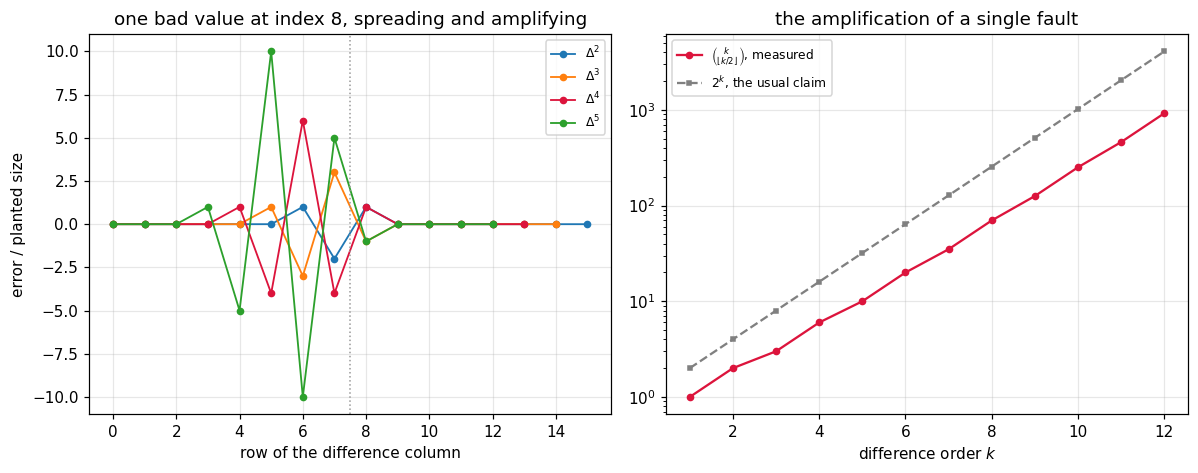

In [11]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

base = np.sin(0.2 * np.arange(18))
planted_at, planted_size = 8, 0.05
bad = base.copy()
bad[planted_at] += planted_size
for k, colour in ((2, "tab:blue"), (3, "tab:orange"), (4, "crimson"), (5, "tab:green")):
    col = fd.forward(bad, k) - fd.forward(base, k)
    ax_left.plot(np.arange(col.size), col / planted_size, "o-", ms=4, lw=1.2,
                 color=colour, label=f"$\\Delta^{k}$")
ax_left.axvline(planted_at - 0.5, color="0.6", lw=1.0, ls=":")
ax_left.set_title(f"one bad value at index {planted_at}, spreading and amplifying")
ax_left.set_xlabel("row of the difference column")
ax_left.set_ylabel("error / planted size")
ax_left.legend(fontsize=8)

orders = np.arange(1, 13)
central = [math.comb(int(k), int(k) // 2) for k in orders]
ax_right.semilogy(orders, central, "o-", ms=4, color="crimson",
                  label=r"$\binom{k}{\lfloor k/2\rfloor}$, measured")
ax_right.semilogy(orders, 2.0 ** orders, "s--", ms=3, color="0.5",
                  label=r"$2^k$, the usual claim")
ax_right.set_title("the amplification of a single fault")
ax_right.set_xlabel("difference order $k$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel shows the pattern the technique looks for, and how it grows and widens with the
order. The right panel is the correction to the folklore: the amplification is the central
binomial coefficient, which is below $2^k$ by a factor of about $\sqrt{\pi k/2}$.

## 9. Exercises

**Level 1, conceptual**

1.1 $\Delta$, $\nabla$ and $\delta$ produce the same numbers on the same data. Say what actually
differs between them, and why all three have names.

1.2 The identity $E = e^{hD}$ is a statement about operators. Say what it means concretely, and
what has to be true of $f$ for it to hold.

1.3 A difference table of measured data has a $\Delta^4$ column that looks like noise. Give two
completely different explanations and the measurement that separates them.

**Level 2, mathematical**

2.1 Prove $\Delta^k f_i = \sum_j (-1)^j \binom{k}{j} f_{i+k-j}$ by induction, and use it to prove
the binomial error pattern of section 6.

2.2 Prove that all six operators commute, by writing each as a series in $E$.

2.3 Derive $hD = \log(1 + \Delta)$ from $E = e^{hD}$, and show that truncating after $m$ terms
gives an $O(h^m)$ approximation to the derivative.

2.4 Show that a degree $d$ polynomial has $\Delta^d f = d!\,a_d h^d$ constant and $\Delta^{d+1} f
= 0$, and use it to derive the divided difference relation
$f[x_i,\dots,x_{i+k}] = \Delta^k f_i / (k!h^k)$.

2.5 Derive the relations $\delta = \Delta E^{-1/2}$, $\mu^2 = 1 + \delta^2/4$ and
$\Delta = \mu\delta + \delta^2/2$, and say which of lesson 49's formulas each one is used in.

**Level 3, computational**

3.1 Implement the **operator calculus symbolically**, so that expressions in $E$, $\Delta$ and
$\delta$ can be expanded and compared automatically, and use it to rederive three of lesson 49's
formulas.

3.2 Implement **Richardson extrapolation** on the difference quotient, using the operator series
to predict the leading error term, and measure the order gained at each level.

3.3 Implement a **difference table fault finder** that handles two independent faults rather than
one, and measure how far apart they must be for it to work.

**Level 4, experimental**

4.1 Measure the amplification of a single fault against the order, fit it, and confirm it is the
central binomial coefficient rather than $2^k$.

4.2 Measure the precondition of section 7 quantitatively: for a family of functions of varying
smoothness, find the largest ratio of intrinsic $\Delta^k$ to fault size at which the technique
still works.

4.3 Measure the accuracy of $hD = \log(1+\Delta)$ against both $m$ and $h$, and find the
combination minimising the error, comparing with lesson 45's optimal spacing argument.

**Level 5, advanced**

5.1 **The umbral calculus.** The formal manipulation of these operators as if they were numbers
has a rigorous foundation. Describe it, and say which manipulations it licenses that a naive
reading does not.

5.2 **Why the operator series diverges and still works.** $\log(1+\Delta)$ is a series in an
operator with no small parameter. Explain in what sense it converges, and what has to be assumed
about $f$.

5.3 **Difference tables in the age of computers.** These techniques were designed for hand
computation on printed tables. Identify which of them are still used, in what settings, and which
have been genuinely superseded and by what.

## 10. Key takeaways

- **Equal spacing turns divided differences into an algebra.** Every divided difference becomes
  $\Delta^k f_i / (k!h^k)$, and the operators can then be manipulated as ordinary expressions.

- **Six operators, all functions of $E$**: $\Delta = E - 1$, $\nabla = 1 - E^{-1}$,
  $\delta = E^{1/2} - E^{-1/2}$, $\mu = \frac12(E^{1/2} + E^{-1/2})$, and $E = e^{hD}$.

- **$E = e^{hD}$ generates everything.** Inverting it gives $hD = \log(1+\Delta)$, and truncating
  after $m$ terms gives an $O(h^m)$ derivative formula, measured at exactly that order for
  $m = 1$ to 4.

- **They all commute and are linear**, which is the licence lesson 49 uses to rearrange them.

- **A degree $d$ polynomial has constant $d$-th differences**, equal to $d!\,a_d h^d$, which is
  the classical test for the degree of tabulated data.

- **A single fault spreads in the binomial pattern and is amplified by the central binomial
  coefficient**, measured at 2, 3, 6, 10, 20 for orders 2 to 6, against $2^k$ of 4, 8, 16, 32, 64.

- **The fault finder has a precondition and it is checkable.** The fault must exceed the data's
  own $k$-th differences. On $\exp(0.3k)$ with a ratio of 11.1 the method returns index 11 for a
  fault at index 5, and the binomial pattern check flags it as unreliable in exactly those cases.

## Where this goes next

Lesson 49 rearranges this algebra into the classical interpolation formulas, and finds that the
choice between them is not primarily about convergence speed. Part 9 uses $hD = \log(1+\Delta)$ as
the source of every numerical differentiation formula, and meets lesson 45's U curve again as the
central practical fact.